In [17]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import load_model
import cv2
import numpy as np

In [12]:
class Patches(layers.Layer):
    def __init__(self, patch_size, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]

        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1,1,1,1],
            padding="VALID",
        )

        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches

In [13]:
class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.projection = layers.Dense(projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )

    def call(self, patch):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        encoded = self.projection(patch) + self.position_embedding(positions)
        return encoded

In [14]:
model = tf.keras.models.load_model(
    "/Users/samarpanpoudel/Desktop/Research/Models/vit_model.h5",
    custom_objects={
        "Patches": Patches,
        "PatchEncoder": PatchEncoder
    }
)

In [16]:
IMG_SIZE = 256  

def preprocess_image(img):
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    return img/255.0

In [18]:
def predict_fn(images):
    images = np.array([preprocess_image(img) for img in images])
    return model.predict(images)

In [19]:
image_path = "/Users/samarpanpoudel/Desktop/Research/Predictions:CNN/false_cases/001.png"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

In [20]:
from lime import lime_image
from skimage.segmentation import mark_boundaries

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [21]:
explainer = lime_image.LimeImageExplainer()

explanation = explainer.explain_instance(
    image=image,
    classifier_fn=predict_fn,
    top_labels=1,
    hide_color=0,
    num_samples=1000
)

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step


  1%|          | 10/1000 [00:00<00:45, 21.55it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


  2%|▏         | 20/1000 [00:00<00:27, 35.73it/s]

...

 98%|█████████▊| 980/1000 [00:14<00:00, 73.60it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


 99%|█████████▉| 990/1000 [00:14<00:00, 73.83it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


100%|██████████| 1000/1000 [00:14<00:00, 69.08it/s]
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packa

In [22]:
import numpy as np

def get_lime_importance_vector(explanation, label, positive_only=False):
    # Total number of superpixels
    segments = explanation.segments
    num_superpixels = np.unique(segments).shape[0]
    
    # Initialize vector with zeros
    importance_vector = np.zeros(num_superpixels)
    
    # Get list of (superpixel_id, weight)
    local_exp = explanation.local_exp[label]
    
    for superpixel_id, weight in local_exp:
        
        if positive_only:
            weight = max(0, weight)
        
        importance_vector[superpixel_id] = weight
    
    return importance_vector

In [23]:
label = explanation.top_labels[0]

vector= get_lime_importance_vector(explanation, label)

print(vector.shape)

(46,)


In [24]:
predicted_class = np.argmax(predict_fn([image]))

temp, mask = explanation.get_image_and_mask(
    label=predicted_class,
    positive_only=True,
    num_features=10,
    hide_rest=False
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step


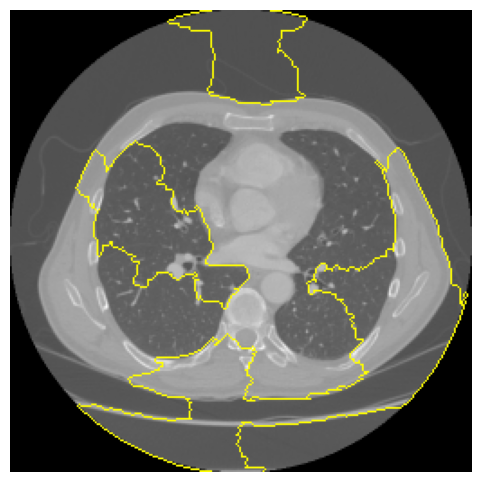

In [27]:
plt.figure(figsize=(6, 6))
plt.imshow(mark_boundaries(temp, mask))
plt.axis("off")
plt.show()